In [1]:
library(devtools)
library(data.table)
library(ggplot2)
library(ggrastr)
setwd('/well/lindgren/UKBIOBANK/flassen/projects/KO/wes_ko_ukbb/')

Loading required package: usethis



In [2]:
devtools::load_all('/well/lindgren/UKBIOBANK/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/ukbtools')

i Loading ukbtools

Loading required package: tidyverse

-- Attaching packages ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ tidyverse 1.3.1 --

v tibble  3.1.5     v dplyr   1.0.7
v tidyr   1.1.4     v stringr 1.4.0
v readr   1.4.0     v forcats 0.5.1
v purrr   0.3.4     

-- Conflicts --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- tidyverse_conflicts() --
x dplyr::between()   masks data.table::between()
x dplyr::filter()    masks stats::filter()
x dplyr::first()     masks data.table::first()
x dplyr::lag()       masks stats::lag()
x dplyr::last()      masks data.table::last()
x purrr::transpose() masks data.table::transpose()

! Adding files missing in collate: /gpfs3/well/lindgren/UKBIOBANK/flassen/proje

In [3]:
# For each phenotype assocation
# * how many compound hetz knockouts
# * how many homozygous knockouts
# * how many completely PTV knockouts
# * how many completely missense knockouts
# * how many mixed knockouts

In [4]:
# knockout counts
knockouts <- list.files('derived/knockouts/211111/', full.names = TRUE)

# phenotypes
pheno_binary <- unlist(strsplit(readLines('data/phenotypes/UKBB_WES200k_binary_phenotypes_header.txt'), split = '\t'))
pheno_cts <- unlist(strsplit(readLines('data/phenotypes/UKBB_WES200k_cts_phenotypes_header.txt'), split = '\t'))

# saige results
saige_binary <- list.files('data/saige/output/combined/binary/step2/211111/', full.names = TRUE)

# thresholds
mutations <- c('ptv','ptv_damaging_missense','synonymous')
mafs <- c('00_01','01_50','00_50')

In [31]:
load_saige_bundle <- function(files, maf, mutation,pheno){
    
    # set thresholds
    #maf = '00_01'
    #pheno = "Cirrhosis"
    #mutation = 'ptv_damaging_missense'

    # subset files
    pheno_mutation = paste0(mutation,'_',pheno)
    bool_maf = grepl(maf, saige_binary)
    bool_pheno = grepl(pheno, saige_binary)
    bool_mutation = grepl(pheno_mutation, saige_binary)

    # load files
    files <- saige_binary[bool_pheno & bool_mutation & bool_maf]
    stopifnot(length(files) > 0)
    combined <- setDT(do.call(rbind, lapply(files, fread)))
    
    # add analytical uniform expecation
    n <- nrow(combined)
    combined <- combined[order(combined$p.value),]
    combined$pvalue.observed <- combined$p.value
    combined$pvalue.expected <- seq(1, n)/(n + 1)
    
    # clean up
    colnames(combined)[colnames(combined)=='SNPID'] <- 'gene_id'
    
    return(combined)
    
}

load_knockout_bundle <- function(files, maf, mutation){
    
    # subset to files
    bool_maf = grepl(maf, files)
    mutation_file = paste0(mutation,'_','knockouts')
    bool_mutation = grepl(mutation_file, files)

    # load files
    files <- files[bool_mutation & bool_maf]
    stopifnot(length(files) > 0)
    combined <- setDT(do.call(rbind, lapply(files, zcat)))
 
    # aggregate knockouts type by gene id
    dt <- data.table(table(combined$gene_id, combined$csqs))
    dt <- data.table::dcast(dt, V1 ~ V2, value.var = 'N')
    colnames(dt)[1] <- 'gene_id'
    
    # clean up outout
    if ('CH+HO' %in% colnames(dt)){
        dt$HO <- dt$HO + dt$`CH+HO`
        dt$`CH+HO` <- NULL
    }
    
    # aggregate alleles by gene id
    #na_collapse <- function(x) paste0(unique(na.omit(x)), collapse = ';')
    #rsids_combined <- apply(combined[,c('phase1','phase2')], 1, na_collapse)
    #rsids_combined <- gsub('(\\[)|(\\])|(\\")', '', rsids_combined)
    #combined$rsids <- rsids_combined
    
    #dt_alleles <- combined[,c('gene_id','rsids')]
    #dt_alleles <- dt_alleles[!duplicated(dt_alleles),]

    # combine alleles and knockouts
    #dt <- merge(dt, dt_alleles, all.x = TRUE)
    

    return(dt)
}

load_knockout_bundle_category <- function(x) {} ## stratify by allele category


In [32]:
maf = '01_50'
pheno = 'Cirrhosis'
mutation = 'ptv_damaging_missense'
kos <- load_knockout_bundle(knockouts, maf, mutation)

In [33]:
kos

gene_id,CH,HE,HO
<chr>,<int>,<int>,<int>
ENSG00000004846,0,41156,24648
ENSG00000006555,0,22507,3960
ENSG00000006607,0,3829,99
ENSG00000007001,0,3540,83
ENSG00000007174,0,29885,8205
ENSG00000010704,0,12770,1143
ENSG00000014216,0,13133,1110
ENSG00000018408,0,13840,1287
ENSG00000021461,0,5901,196


In [6]:
maf = '01_50'
pheno = 'Cirrhosis'
mutation = 'ptv_damaging_missense'

dts <- load_saige_bundle(saige_binary, maf, mutation, pheno)
kos <- load_knockout_bundle(knockouts, maf, mutation)
mrg <- merge(dts, kos, by = 'gene_id', all.x = TRUE)

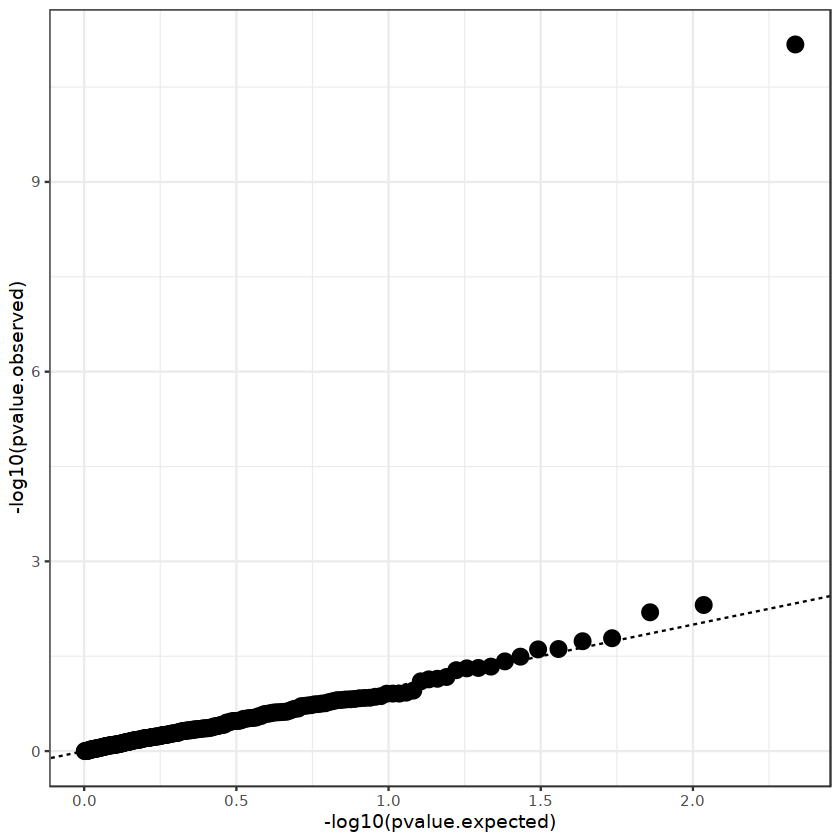

In [7]:
ggplot(mrg, aes(x=-log10(pvalue.expected), y = -log10(pvalue.observed))) +
    geom_point(size = 4) +
    geom_abline(linetype = 'dashed') + 
    theme_bw()

In [8]:
mutations

[1] "ptv"                   "ptv_damaging_missense" "synonymous"

In [9]:
for (phenotype in c('Cirrhosis')){
    outlist <- list()
    for (maf in c('01_50')){
        for (mutation in mutations){
            print(mutation)
            id <- paste0(pheno,maf,mutation, sep = '_')
            print(id)
            dts <- load_saige_bundle(saige_binary, maf, mutation, pheno)
            kos <- load_knockout_bundle(knockouts, maf, mutation)
            mrg <- merge(dts, kos, by = 'gene_id', all.x = TRUE)
            mrg$phenotype <- phenotype
            mrg$maf <- maf 
            mrg$mutation <- mutation
            outlist[[id]] <- mrg
        }
    }     
    combined <- as.data.table(do.call(rbind, outlist))
}


    

In [ ]:
ggplot(combined, aes(x=-log10(pvalue.expected), y = -log10(pvalue.observed), color = mutation)) +
    geom_point(size = 4) +
    geom_abline(linetype = 'dashed') + 
    theme_bw() +
    facet_wrap(mutation ~ maf)

In [12]:

maf = '00_50'
mutation = 'ptv'
files = knockouts
# subset to files
    bool_maf = grepl(maf, files)
    mutation_file = paste0(mutation,'_','knockouts')
    bool_mutation = grepl(mutation_file, files)

    # load files
    files <- files[bool_mutation & bool_maf]
    stopifnot(length(files) > 0)
    combined <- setDT(do.call(rbind, lapply(files, zcat)))
 
    # aggregate by gene id
    dt <- data.table(table(combined$gene_id, combined$csqs))
    dt <- data.table::dcast(dt, V1 ~ V2, value.var = 'N')
    colnames(dt)[1] <- 'gene_id'



In [20]:
combined <- head(combined[combined$csqs == 'CH'])
x <- combined

In [21]:
na_collapse <- function(x) paste0(na.omit(x), collapse = ';')
rsids_combined <- apply(x[,c('phase1','phase2')], 1, na_collapse)
rsids_combined <- gsub('(\\[)|(\\])|(\\")', '', rsids_combined)

In [22]:
rsids_combined

[1] "chr10_104275224_A_G;chr10_104299178_G_A"     
[2] "chr10_50097803_G_A;chr10_50068169_G_A"       
[3] "chr10_50097803_G_A;chr10_50068169_G_A"       
[4] "chr10_50068169_G_A;chr10_50097803_G_A"       
[5] "chr10_16940152_G_A;chr10_16836383_C_T"       
[6] "chr10_17068706_G_C;chr10_16918687_ATAACCTC_A"